#1. Install Libraries

In [53]:
!pip install -q kagglehub

#2. Import Libraries

In [54]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    RocCurveDisplay
)

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")

#3. Download Dataset

In [55]:
import kagglehub

path = kagglehub.dataset_download("iammustafatz/diabetes-prediction-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'diabetes-prediction-dataset' dataset.
Path to dataset files: /kaggle/input/diabetes-prediction-dataset


In [56]:
import os

print(os.listdir(path))

['diabetes_prediction_dataset.csv']


#4. Load Dataset

In [57]:
df = pd.read_csv(file_path)

# Randomly select 50,000 rows
df = df.sample(
    n=50000,
    random_state=42
).reset_index(drop=True)

print("Dataset shape:", df.shape)

Dataset shape: (50000, 9)


#5. Basic EDA

#Dataset Shape

In [58]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 50000
Columns: 9


#Dataset Information

In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   gender               50000 non-null  object 
 1   age                  50000 non-null  float64
 2   hypertension         50000 non-null  int64  
 3   heart_disease        50000 non-null  int64  
 4   smoking_history      50000 non-null  object 
 5   bmi                  50000 non-null  float64
 6   HbA1c_level          50000 non-null  float64
 7   blood_glucose_level  50000 non-null  int64  
 8   diabetes             50000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 3.4+ MB


#Statistical Summary

In [60]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
gender,50000,3,Female,29347,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,50000.0,NaN,NaN,NaN,41.961291,22.527404,0.08,24.0,43.0,60.0,80.0
hypertension,50000.0,NaN,NaN,NaN,0.07356,0.261056,0.0,0.0,0.0,0.0,1.0
heart_disease,50000.0,NaN,NaN,NaN,0.03874,0.192977,0.0,0.0,0.0,0.0,1.0
smoking_history,50000,6,No Info,17833,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bmi,50000.0,NaN,NaN,NaN,27.34414,6.686656,10.19,23.62,27.32,29.58,95.69
HbA1c_level,50000.0,NaN,NaN,NaN,5.527746,1.070485,3.5,4.8,5.8,6.2,9.0
blood_glucose_level,50000.0,NaN,NaN,NaN,137.8884,40.658331,80.0,100.0,140.0,159.0,300.0
diabetes,50000.0,NaN,NaN,NaN,0.08518,0.279152,0.0,0.0,0.0,0.0,1.0


#Column Names

In [61]:
print(df.columns.tolist())

['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes']


#6. Check Missing Values

In [62]:
df.isnull().sum()

,0
gender,0
age,0
hypertension,0
heart_disease,0
smoking_history,0
bmi,0
HbA1c_level,0
blood_glucose_level,0
diabetes,0


In [63]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum() / len(df)) * 100
})

missing

,Missing Values,Percentage
gender,0,0.0
age,0,0.0
hypertension,0,0.0
heart_disease,0,0.0
smoking_history,0,0.0
bmi,0,0.0
HbA1c_level,0,0.0
blood_glucose_level,0,0.0
diabetes,0,0.0


#7. Duplicate Values

In [64]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 1084


In [65]:
df = df.drop_duplicates().reset_index(drop=True)

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (48916, 9)


#8. Target Variable Analysis

In [66]:
df["diabetes"].value_counts()

,count
diabetes,
0,44658
1,4258


In [67]:
print(
    df["diabetes"].value_counts(normalize=True) * 100
)

diabetes
0    91.295282
1     8.704718
Name: proportion, dtype: float64


#Target Distribution

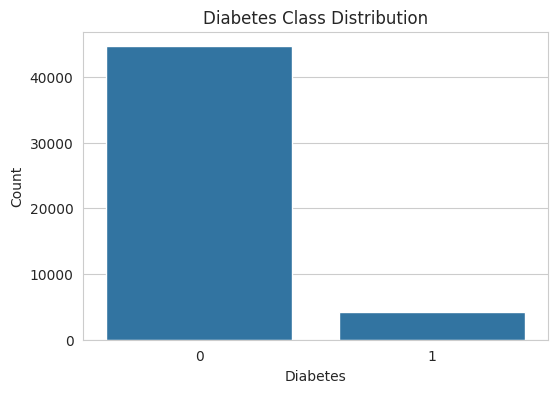

In [68]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="diabetes"
)

plt.title("Diabetes Class Distribution")
plt.xlabel("Diabetes")
plt.ylabel("Count")
plt.show()

#9. Numerical Columns

In [69]:
numerical_features = df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

numerical_features

['age',
 'hypertension',
 'heart_disease',
 'bmi',
 'HbA1c_level',
 'blood_glucose_level',
 'diabetes']

In [70]:
numerical_features.remove("diabetes")

numerical_features

['age',
 'hypertension',
 'heart_disease',
 'bmi',
 'HbA1c_level',
 'blood_glucose_level']

#10. Categorical Columns

In [71]:
categorical_features = df.select_dtypes(
    include=["object"]
).columns.tolist()

categorical_features

['gender', 'smoking_history']

#11. Numerical Features Distribution

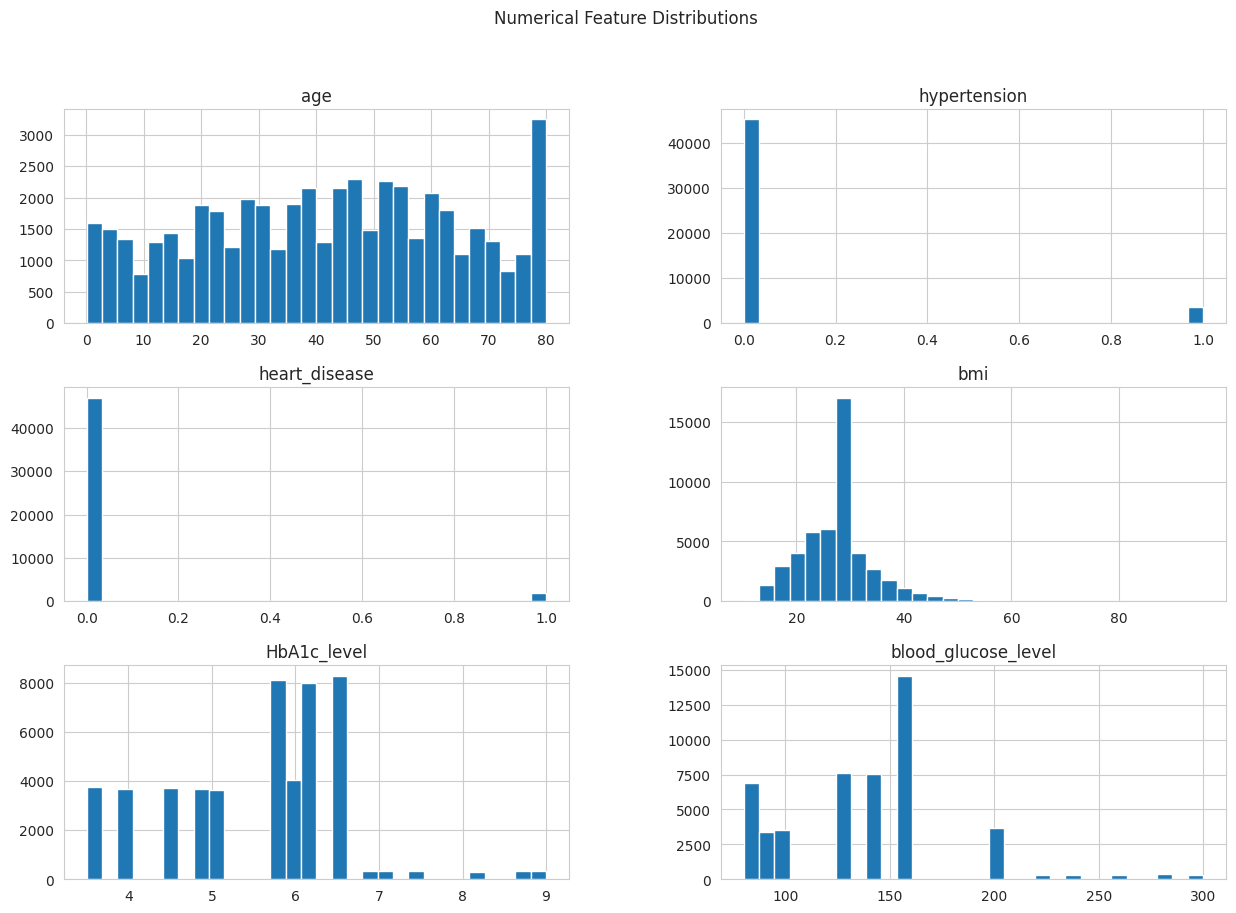

In [72]:
df[numerical_features].hist(
    figsize=(15,10),
    bins=30
)

plt.suptitle("Numerical Feature Distributions")
plt.show()

#12. Boxplots

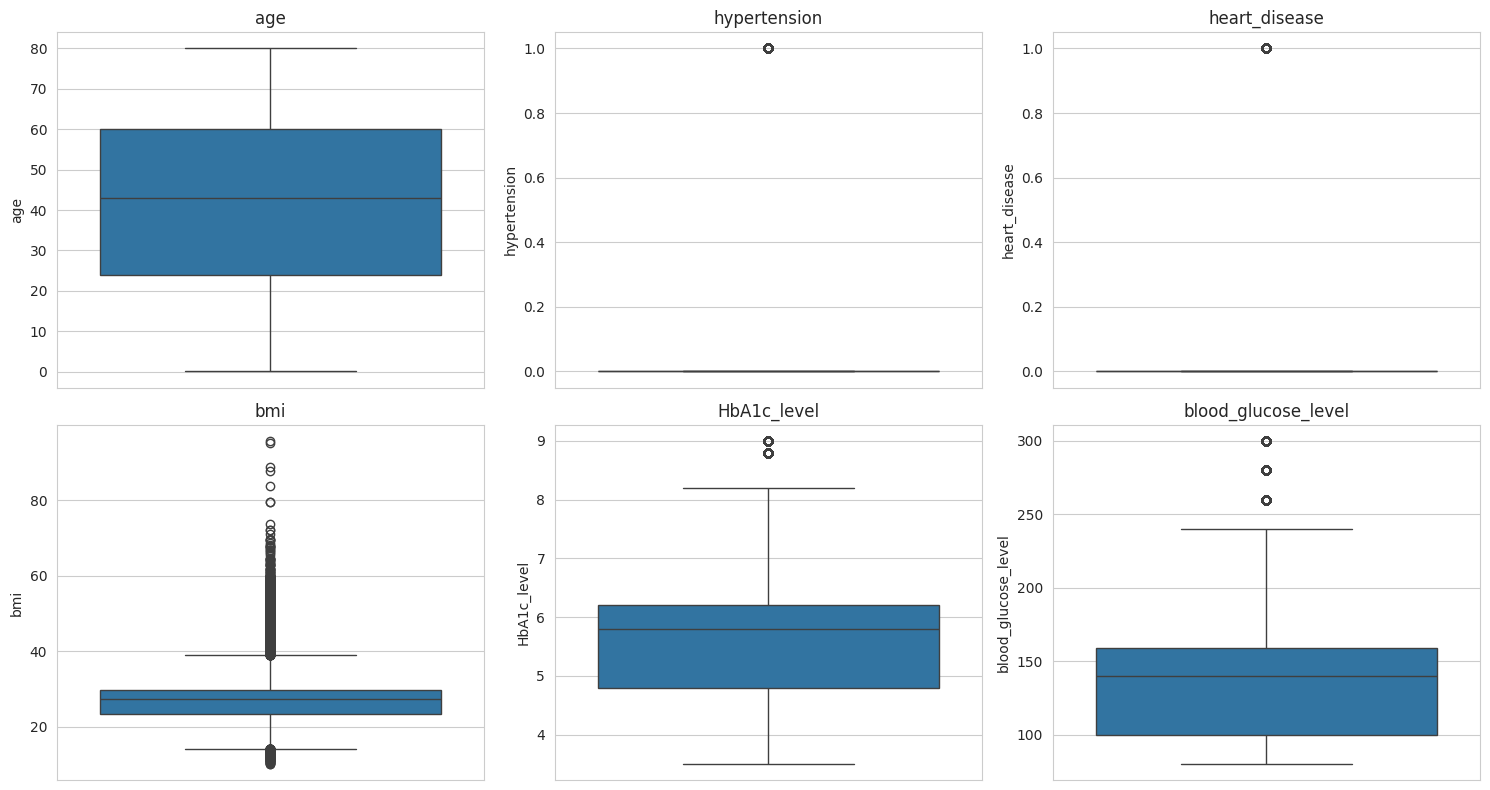

In [73]:
plt.figure(figsize=(15,8))

for i, col in enumerate(numerical_features, 1):

    plt.subplot(2, 3, i)

    sns.boxplot(
        y=df[col]
    )

    plt.title(col)

plt.tight_layout()
plt.show()

#13. Correlation Heatmap

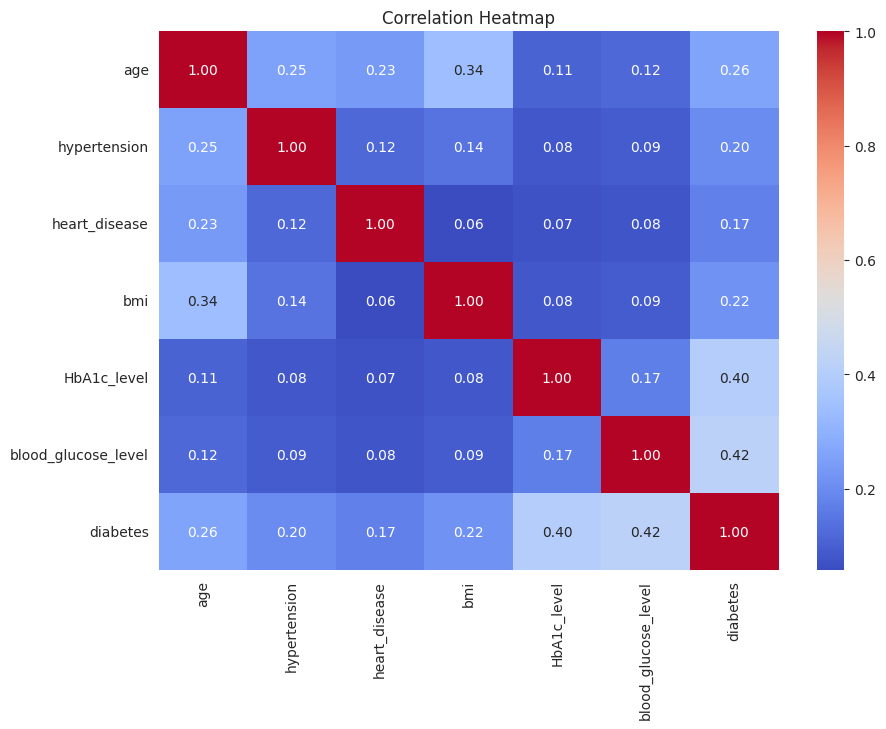

In [74]:
plt.figure(figsize=(10,7))

correlation = df[numerical_features + ["diabetes"]].corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

#14. Categorical Feature Analysis

***Gender vs Diabetes***

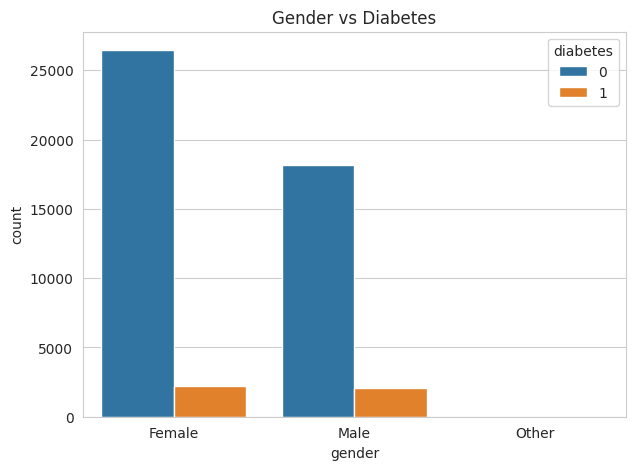

In [75]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="gender",
    hue="diabetes"
)

plt.title("Gender vs Diabetes")
plt.show()

***Smoking History vs Diabetes***

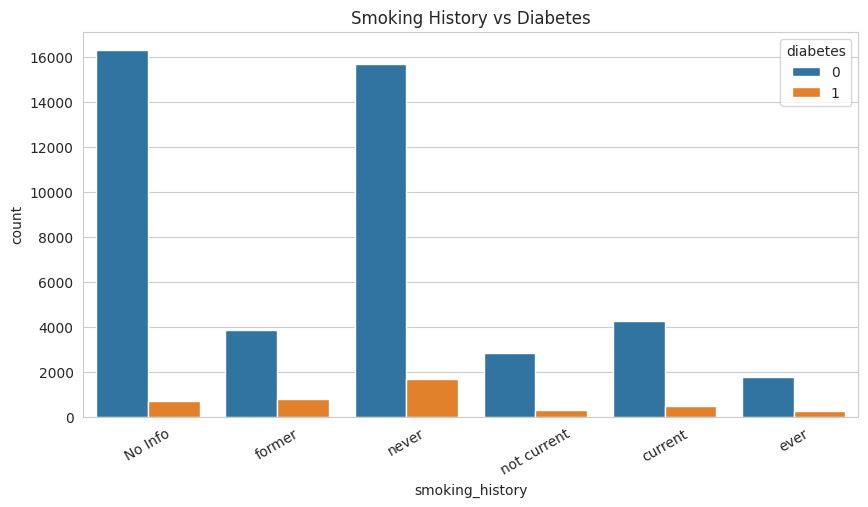

In [76]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="smoking_history",
    hue="diabetes"
)

plt.title("Smoking History vs Diabetes")
plt.xticks(rotation=30)
plt.show()

#15. Feature vs Diabetes

***Age***

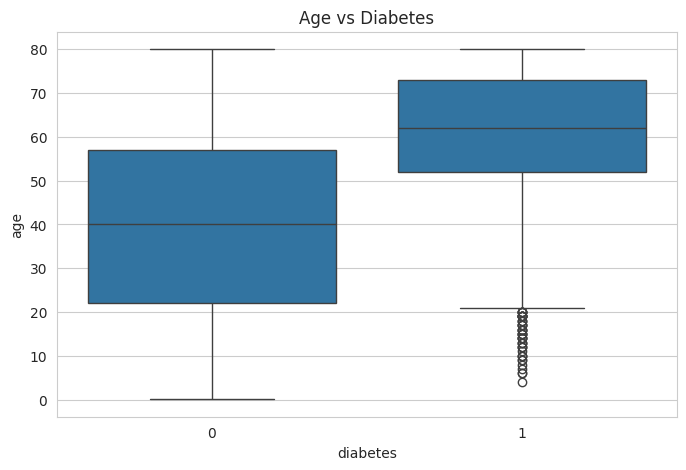

In [77]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="diabetes",
    y="age"
)

plt.title("Age vs Diabetes")
plt.show()

***BMI***

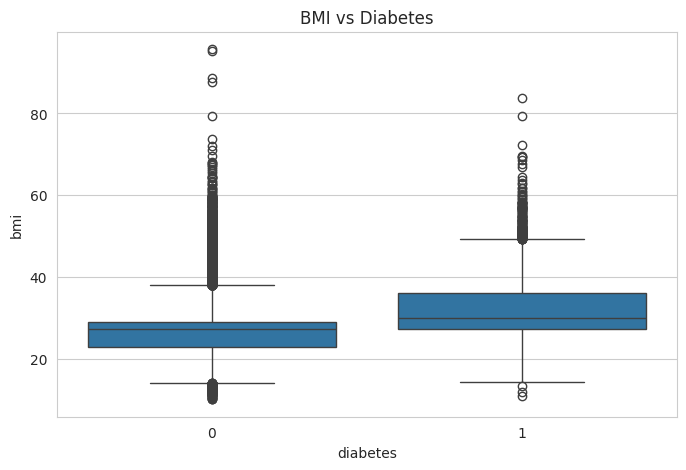

In [78]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="diabetes",
    y="bmi"
)

plt.title("BMI vs Diabetes")
plt.show()

***HbA1c Level***

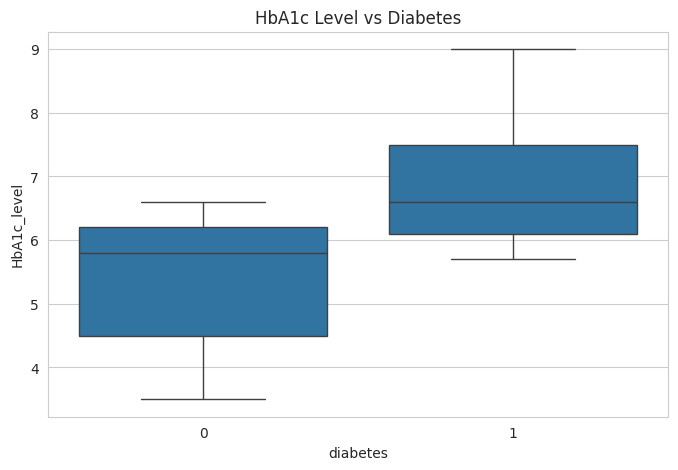

In [79]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="diabetes",
    y="HbA1c_level"
)

plt.title("HbA1c Level vs Diabetes")
plt.show()

***Blood Glucose Level***

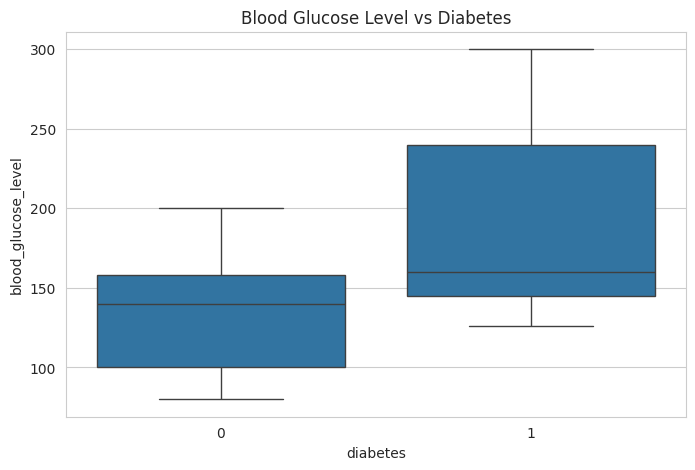

In [80]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="diabetes",
    y="blood_glucose_level"
)

plt.title("Blood Glucose Level vs Diabetes")
plt.show()

#16. Prepare X and y

In [81]:
X = df.drop("diabetes", axis=1)

y = df["diabetes"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (48916, 8)
y shape: (48916,)


#17. Train-Test Split

In [82]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (39132, 8)
Testing data: (9784, 8)


#18. Preprocessing Pipeline

In [83]:
numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical:", numerical_features)
print("Categorical:", categorical_features)

Numerical: ['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level']
Categorical: ['gender', 'smoking_history']


***Numerical Pipeline***

In [84]:
numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

***Categorical Pipeline***

In [85]:
categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(
            handle_unknown="ignore"
        ))
    ]
)

***Column Transformer***

In [86]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_pipeline,
            numerical_features
        ),
        (
            "cat",
            categorical_pipeline,
            categorical_features
        )
    ]
)

#19. Logistic Regression Pipeline

In [87]:
logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

In [88]:
logistic_pipeline.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'hypertension',
                                                   'heart_disease', 'bmi',
                                                   'HbA1c_level',
                                                   'blood_glucose_level']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender',
                                                   'smoking_history'])])),
                ('model', LogisticRegression(max_iter=1000, random_state=42))])

In [89]:
y_pred_lr = logistic_pipeline.predict(X_test)

y_prob_lr = logistic_pipeline.predict_proba(
    X_test
)[:, 1]

#20. SVM Pipeline

In [90]:
svm_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            SVC(
                kernel="rbf",
                probability=True,
                random_state=42
            )
        )
    ]
)

In [91]:
svm_pipeline.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'hypertension',
                                                   'heart_disease', 'bmi',
                                                   'HbA1c_level',
                                                   'blood_glucose_level']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender',
                                                   'smoking_history'])])),
                ('model', SVC(probability=True, random_state=42))])

In [92]:
y_pred_svm = svm_pipeline.predict(X_test)

y_prob_svm = svm_pipeline.predict_proba(
    X_test
)[:, 1]

#21. Random Forest Pipeline

In [93]:
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=200,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [94]:
rf_pipeline.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'hypertension',
                                                   'heart_disease', 'bmi',
                                                   'HbA1c_level',
                                                   'blood_glucose_level']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender',
                                                   'smoking_history'])])),
                ('model',
                 RandomForestClassifier(n_estimators=200, n_jobs=-1,
                                        random_state=42))])

In [95]:
y_pred_rf = rf_pipeline.predict(X_test)

y_prob_rf = rf_pipeline.predict_proba(
    X_test
)[:, 1]

#22. XGBoost Pipeline

In [96]:
xgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            XGBClassifier(
                n_estimators=200,
                learning_rate=0.05,
                max_depth=5,
                subsample=0.8,
                colsample_bytree=0.8,
                eval_metric="logloss",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [97]:
xgb_pipeline.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'hypertension',
                                                   'heart_disease', 'bmi',
                                                   'HbA1c_level',
                                                   'blood_glucose_level']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=200, n_jobs=-1,
                               num_parallel_tree=None, ...))])

In [98]:
y_pred_xgb = xgb_pipeline.predict(X_test)

y_prob_xgb = xgb_pipeline.predict_proba(
    X_test
)[:, 1]

#23. Model Evaluation Function

In [99]:
def evaluate_model(name, y_true, y_pred, y_prob):

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    precision = precision_score(
        y_true,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        zero_division=0
    )

    auc = roc_auc_score(
        y_true,
        y_prob
    )

    print("=" * 60)
    print(name)
    print("=" * 60)

    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")
    print(f"ROC-AUC   : {auc:.4f}")

    print("\nClassification Report:")
    print(
        classification_report(
            y_true,
            y_pred,
            zero_division=0
        )
    )

    return {
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": auc
    }

#24. Evaluate All 4 Models

In [100]:
results = []

results.append(
    evaluate_model(
        "Logistic Regression",
        y_test,
        y_pred_lr,
        y_prob_lr
    )
)

results.append(
    evaluate_model(
        "SVM",
        y_test,
        y_pred_svm,
        y_prob_svm
    )
)

results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        y_pred_rf,
        y_prob_rf
    )
)

results.append(
    evaluate_model(
        "XGBoost",
        y_test,
        y_pred_xgb,
        y_prob_xgb
    )
)

Logistic Regression
Accuracy  : 0.9588
Precision : 0.8524
Recall    : 0.6373
F1 Score  : 0.7293
ROC-AUC   : 0.9622

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      8932
           1       0.85      0.64      0.73       852

    accuracy                           0.96      9784
   macro avg       0.91      0.81      0.85      9784
weighted avg       0.96      0.96      0.96      9784

SVM
Accuracy  : 0.9628
Precision : 0.9784
Recall    : 0.5857
F1 Score  : 0.7327
ROC-AUC   : 0.9211

Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98      8932
           1       0.98      0.59      0.73       852

    accuracy                           0.96      9784
   macro avg       0.97      0.79      0.86      9784
weighted avg       0.96      0.96      0.96      9784

Random Forest
Accuracy  : 0.9697
Precision : 0.9498
Recall    : 0.6890
F1 Score  : 0

#25. Model Comparison

In [101]:
results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.958810,0.852433,0.637324,0.729349,0.962167
1,SVM,0.962796,0.978431,0.585681,0.732746,0.921139
2,Random Forest,0.969747,0.949838,0.688967,0.798639,0.960448
3,XGBoost,0.971893,0.984874,0.687793,0.809952,0.978760


In [102]:
results_df.sort_values(
    by="ROC-AUC",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
3,XGBoost,0.971893,0.984874,0.687793,0.809952,0.978760
0,Logistic Regression,0.958810,0.852433,0.637324,0.729349,0.962167
2,Random Forest,0.969747,0.949838,0.688967,0.798639,0.960448
1,SVM,0.962796,0.978431,0.585681,0.732746,0.921139


#26. Visual Model Comparison

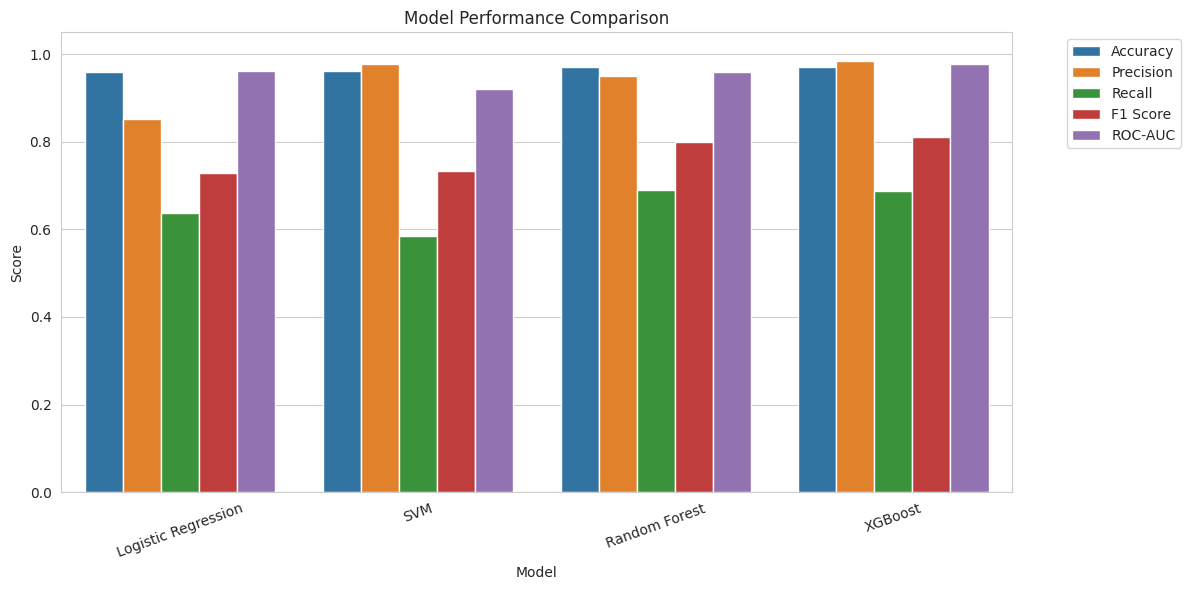

In [103]:
plt.figure(figsize=(12,6))

results_melted = results_df.melt(
    id_vars="Model",
    value_vars=[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    var_name="Metric",
    value_name="Score"
)

sns.barplot(
    data=results_melted,
    x="Model",
    y="Score",
    hue="Metric"
)

plt.title("Model Performance Comparison")
plt.ylim(0, 1.05)
plt.xticks(rotation=20)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

#27. Confusion Matrix — All Models

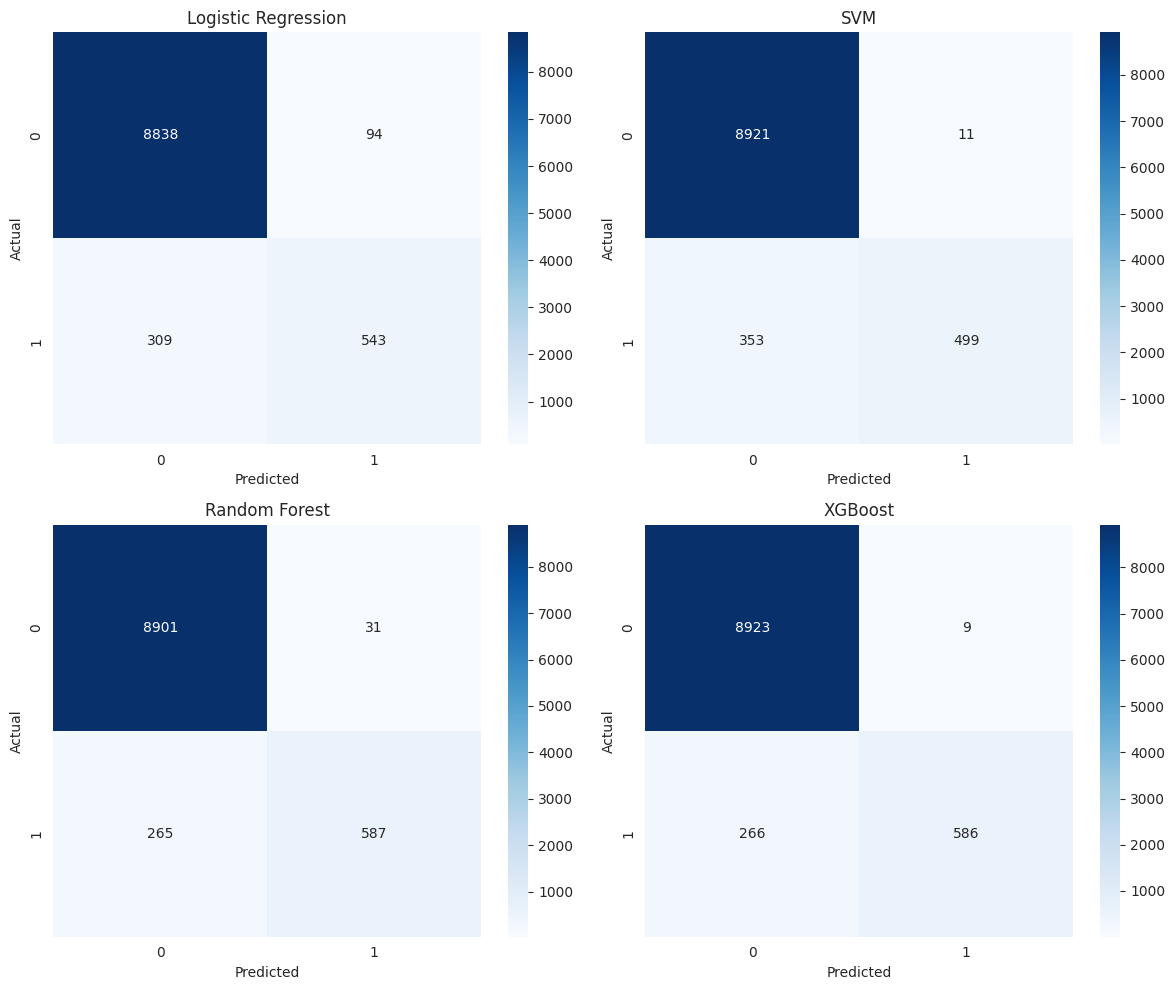

In [104]:
models_predictions = {
    "Logistic Regression": y_pred_lr,
    "SVM": y_pred_svm,
    "Random Forest": y_pred_rf,
    "XGBoost": y_pred_xgb
}

fig, axes = plt.subplots(
    2, 2,
    figsize=(12,10)
)

for ax, (name, predictions) in zip(
    axes.ravel(),
    models_predictions.items()
):

    cm = confusion_matrix(
        y_test,
        predictions
    )

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=ax
    )

    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

#28. ROC Curves

<Figure size 1000x700 with 0 Axes>

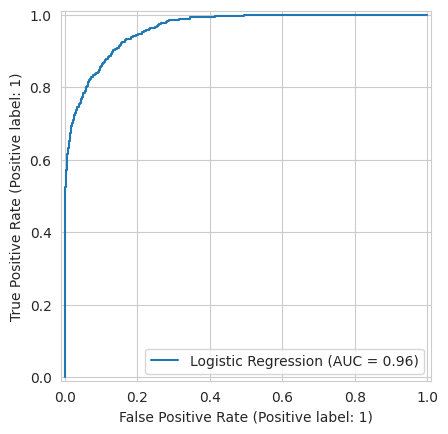

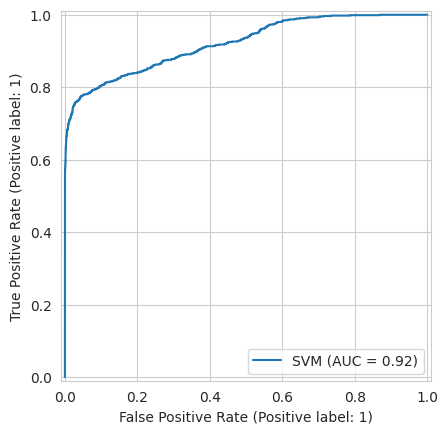

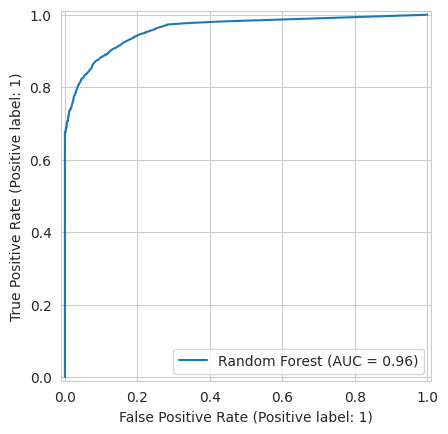

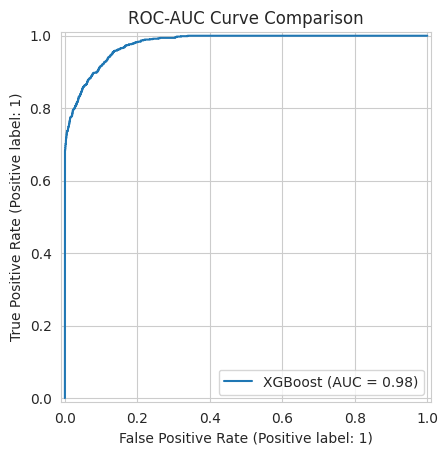

In [105]:
plt.figure(figsize=(10,7))

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_lr,
    name="Logistic Regression"
)

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_svm,
    name="SVM"
)

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_rf,
    name="Random Forest"
)

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_xgb,
    name="XGBoost"
)

plt.title("ROC-AUC Curve Comparison")
plt.grid(True)
plt.show()

#29. Find Best Model

In [106]:
best_model_name = results_df.loc[
    results_df["ROC-AUC"].idxmax(),
    "Model"
]

print("Best Model:", best_model_name)

Best Model: XGBoost


#31. New Patient Prediction

In [107]:
new_patient = pd.DataFrame({
    "gender": ["Female"],
    "age": [45],
    "hypertension": [0],
    "heart_disease": [0],
    "smoking_history": ["never"],
    "bmi": [28.5],
    "HbA1c_level": [5.8],
    "blood_glucose_level": [130]
})

In [108]:
prediction = xgb_pipeline.predict(
    new_patient
)

probability = xgb_pipeline.predict_proba(
    new_patient
)[:, 1]

print("Prediction:", prediction[0])
print("Diabetes Probability:", probability[0])

Prediction: 0
Diabetes Probability: 0.045575716


In [109]:
if prediction[0] == 1:
    print(
        f"Diabetes predicted "
        f"(probability: {probability[0]:.2%})"
    )
else:
    print(
        f"No diabetes predicted "
        f"(probability: {probability[0]:.2%})"
    )

No diabetes predicted (probability: 4.56%)
